In [25]:
import numpy as np
import scipy as sp 
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import pandas as pd
import qiskit as qk

# import Qiskit libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import StatevectorSimulator, AerSimulator
from qiskit.circuit.library import QFTGate

# Qiskit visualization libraries
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector

# Q2 a) i)

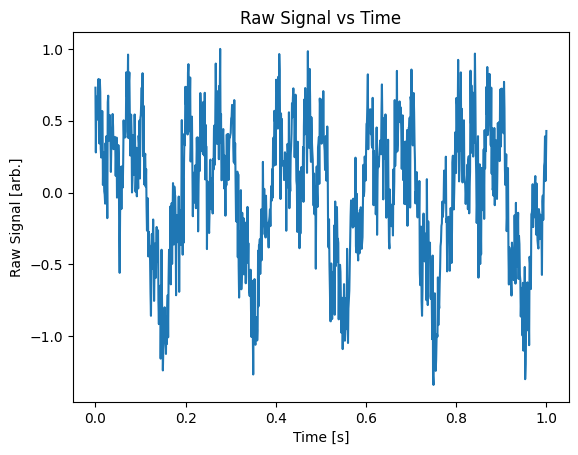

In [26]:
#make sure raw_signal_data.csv is in the same directory as this notebook
times = np.array(pd.read_csv('raw_signal_data.csv')['Time [s]'])
signal = np.array(pd.read_csv('raw_signal_data.csv')['Raw Signal [arb.]'])

#plot signal vs time
plt.plot(times, signal)
plt.xlabel('Time [s]')
plt.ylabel('Raw Signal [arb.]')
plt.title('Raw Signal vs Time')
plt.show()
dt = times[1] - times[0]
def FFT(signal, times, dt):
    N = len(times)
    signal_f = []
    #outer loop is over frequencies, inner loop is over time samples
    for k in range(N):
        sum = 0
        for i in range(N):
            sum += np.exp(-2j*np.pi*k*i/N) * signal[i]
        signal_f.append(sum)
    frequencies = [k/(N*dt) for k in range(N)]
    
    #truncate to only keep up to nyquist frequency
    signal_f = signal_f[:N//2]
    frequencies = frequencies[:N//2]
    return (signal_f, frequencies)
signal_f, frequencies = FFT(signal, times, dt)
# plot the magnitude of the custom FFT vs frequency (interactive)
fig_custom = go.Figure()
fig_custom.add_trace(go.Scatter(x=frequencies, y=np.abs(signal_f), mode='lines', name='Custom FFT'))
fig_custom.update_layout(title='Magnitude of FFT vs Frequency',xaxis_title='Frequency [Hz]',yaxis_title='Magnitude of FFT [arb.]')
fig_custom.show()

#scipy implementation of FFT for comparison
signal_f_scipy = sp.fft.fft(signal)
frequencies_scipy = sp.fft.fftfreq(len(times), dt)
# plot the magnitude of the scipy FFT vs frequency (interactive)
fig_scipy = go.Figure()
fig_scipy.add_trace(go.Scatter(x=frequencies_scipy[:len(frequencies_scipy)//2], y=np.abs(signal_f_scipy)[:len(signal_f_scipy)//2], mode='lines', name='Scipy FFT'))
fig_scipy.update_layout(title='Magnitude of FFT vs Frequency',xaxis_title='Frequency [Hz]',yaxis_title='Magnitude of FFT [arb.]')
fig_scipy.show()    






# Q2 a) ii)
We have frequency peaks at 5.425347, 10.85069 and 32.55208 Hz. We now want to see the relative phase of these peaks. We can do this by looking at the complex values of the FFT values at these frequencies to find the angle in the complex plane. Then we can take the differene of these angles to find the relative phase. 

In [56]:
idx = np.where(np.abs(signal_f) > 50)
print("Frequencies with peaks above 50:", [frequencies[i].round(3)for i in idx[0]])
angles = [np.angle(signal_f[i],deg=True) for i in idx[0]]
print("Angles of peaks above 50:", [angle.round(3) for angle in angles])

phi_5_10 = angles[1] - angles[0]
phi_5_32 = angles[2] - angles[0]
phi_10_32 = angles[2] - angles[1]
print("Relative phase between 5.425347 and 10.85069 Hz:", phi_5_10.round(3), "degrees")
print("Relative phase between 5.425347 and 32.55208 Hz:", phi_5_32.round(3), "degrees")
print("Relative phase between 10.85069 and 32.55208 Hz:", phi_10_32.round(3), "degrees")

Frequencies with peaks above 50: [np.float64(5.425), np.float64(10.851), np.float64(32.552)]
Angles of peaks above 50: [np.float64(-89.767), np.float64(5.213), np.float64(-40.619)]
Relative phase between 5.425347 and 10.85069 Hz: 94.981 degrees
Relative phase between 5.425347 and 32.55208 Hz: 49.148 degrees
Relative phase between 10.85069 and 32.55208 Hz: -45.833 degrees


# Q2 b)
Now we implement a quantum circuit to find the DFT of our signal using the QFT. We can prepare our quantum state to encode it into amplitude representation, apply the QFT, and then measure the output state to get measurement probabilities corresponding to the DFT values.

We encode our signal using amplitude representation which. I am choosing to let each basis state in my input space represent the index of the signal sample point and the associated amplitude of that basis state represents the normalized amplitude of the signal at that sample point. That is $$|{\psi}\rangle = \sum_{k=0}^{N-1} \frac{x[k]}{||x||} |{k}\rangle$$

Normalizing the signal is important to ensure that the quantum state is valid (i.e. has unit norm). This encoding allows us to represent the entire signal in a superposition of basis states, which is necessary for the QFT to compute the DFT efficiently. (i.e. our initial state is a superposition of our signal at all points with the amplitude of each point encoded in the amplitude of the corresponding basis state)

This allows us to process our signal with a single application of the QFT. Since we have 1024 sample points, we can encode our signal into 10 qubits (since $2^{10} = 1024$) and then apply the QFT to get the DFT values in the output state. We can then measure the output state to get the probabilities corresponding to the DFT values. The high level circuit diagram is presented below:

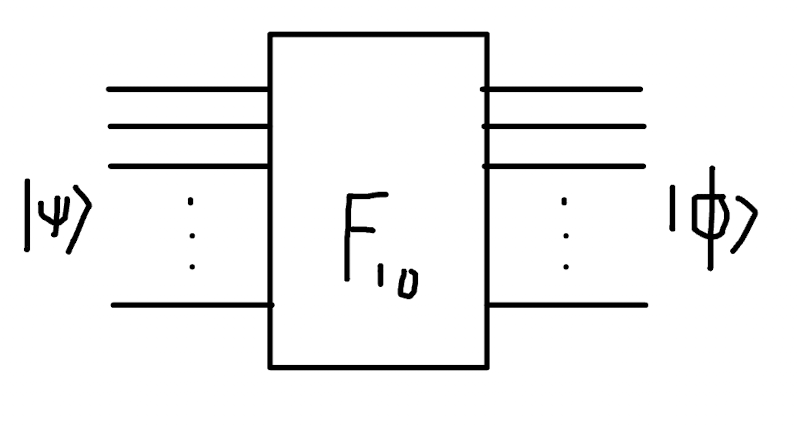

We input our encoded signal, apply the QFT then measure the output state to get the probabilities corresponding to the DFT values. We will use qiskit's initialize function to prepare our input state and then apply the QFT gate (we use qiskit's implementation) to get the DFT values in the output state. We will then measure the output state to get the probabilities corresponding to the DFT values.

If we want to plot our signal or spectrum, we need to convert back our indices to either time or frequency values. We can do this by using the sampling rate and the number of sample points to find the corresponding time or frequency values for each index. For example, if we have a sampling rate of 1024 Hz and 1024 sample points, then each index corresponds to a frequency of $f = \frac{k}{N} \cdot f_s$ where $k$ is the index, $N$ is the number of sample points, and $f_s$ is the sampling rate. This allows us to plot our spectrum with the correct frequency values on the x-axis. 

Similarly we would convert the indices of our time signal by using the sampling rate to find the corresponding time values for each index. For example, if we have a sampling rate of 1024 Hz and 1024 sample points, then each index corresponds to a time of $t = \frac{k}{f_s}$ where $k$ is the index and $f_s$ is the sampling rate. This allows us to plot our time signal with the correct time values on the x-axis.

The code bellow is simply to check that we can prepare/encode our signal readily. 

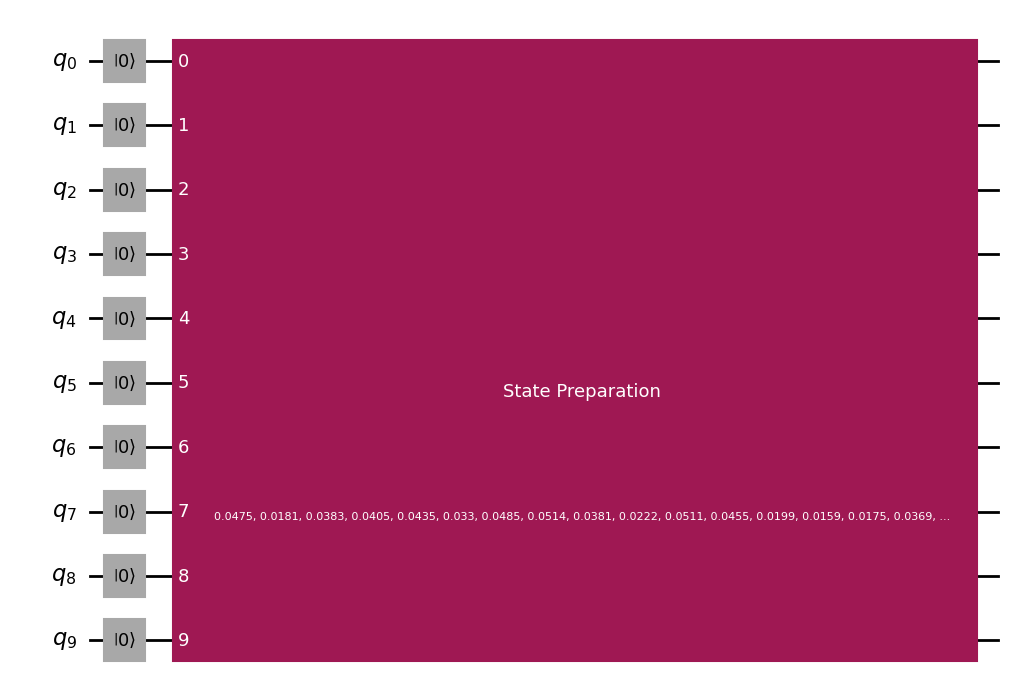

In [48]:
#econdes our signal into a quantum state using amplitude encoding via qiskit initialize. 
def encode_signal(signal):
    #make sure signal is normalized to respect born's rule
    signal = signal / np.linalg.norm(signal)
    N = len(signal)
    n_qubits = int(np.ceil(np.log2(N)))
    qc = QuantumCircuit(n_qubits)
    
    qc.initialize(signal, range(n_qubits))
    return qc

qc_signal = encode_signal(signal)
display(qc_signal.decompose().draw('mpl'))


#simulate the statevector of the encoded signal
simulator = StatevectorSimulator()
qc_signal = transpile(qc_signal, simulator)
result = simulator.run(qc_signal).result()

#get statevector of the encoded signal
statevector = np.array(result.get_statevector())
#signal is encoded in the real part of the state vector.
real_parts = np.real(statevector)

fig = go.Figure()
fig.add_trace(go.Scatter(x=times, y=real_parts, mode='lines', name='Real Part'))
#compare to signal before encoding, makeline dotted and normalized
fig.add_trace(go.Scatter(x=times, y=signal/np.linalg.norm(signal), mode='lines', name='Original Signal (normalized)', line=dict(dash='dot')))
fig.update_layout(title='Real and Imaginary Parts of Statevector', xaxis_title='Time [s]', yaxis_title='Amplitude')
fig.show()

#plot difference between original and reconstructed signal
fig_diff = go.Figure()
fig_diff.add_trace(go.Scatter(x=times, y=real_parts - signal/np.linalg.norm(signal), mode='lines', name='Difference between Real Part and Original Signal (normalized)'))
fig_diff.update_layout(title='Difference between Real Part of Statevector and Original Signal', xaxis_title='Time [s]', yaxis_title='Difference in Amplitude')
fig_diff.show()

So we can see that we reconstruct our signal correctly and we can prepare our quantum state to encode our signal into amplitude representation. As for the QFT part of circuit, this is how the circuit looks like in terms of hadamard, phase and swap gates:

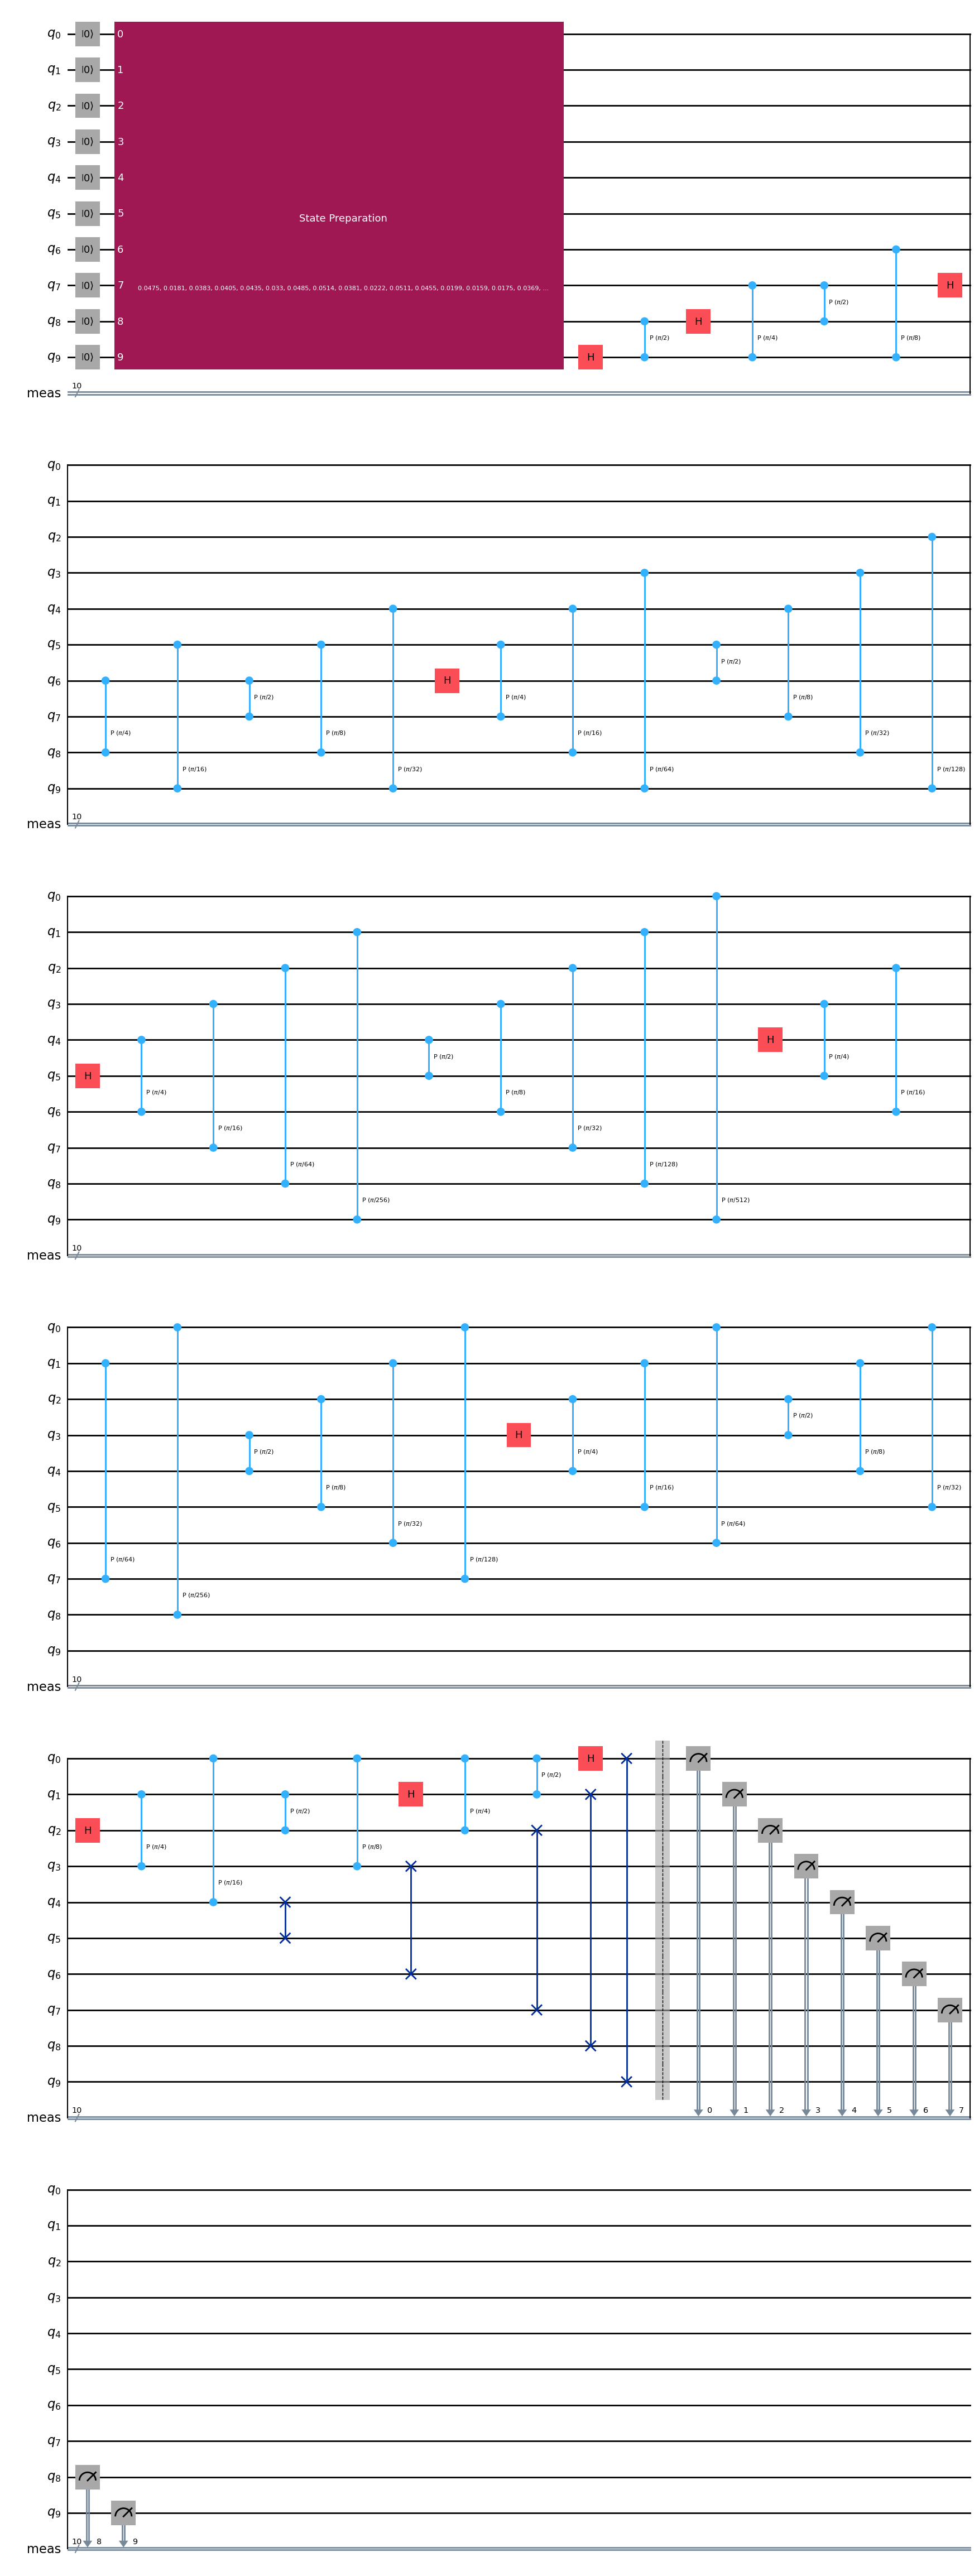

In [31]:
def QFT(signal):
    N = len(signal)
    n_qubits = int(np.ceil(np.log2(N)))
    qc = QuantumCircuit(n_qubits)

    # Encode signal into quantum state
    qc.initialize(signal / np.linalg.norm(signal), range(n_qubits))

    # Apply QFT (we will correct output ordering in post-processing)
    qft_gate = QFTGate(n_qubits)
    qc.append(qft_gate, range(n_qubits))
    qc.measure_all() # add measurement to extract statevector after QFT

    return qc

QFT_circuit = QFT(signal)
display(QFT_circuit.decompose().draw('mpl'))

# Q2 c)
Now we can apply the QFT to our signal to reconstruct the spectrum. We can then compare our reconstructed spectrum to the classical FFT to see how well we did. Using measurements to reconstruct the spectrum will introduce some noise due to the finite number of shots, so we expect to see some differences between the measurement reconstructed spectrum and the classical FFT. We can plot the difference between the two spectra to see how well we did.

Another drawbacks of using measurements is that recovering the relative phase information between the different frequency components is not straightforward. The measurement probabilities only give us the magnitude of the DFT values, but not their phase. This means that we can only reconstruct the magnitude spectrum, but not the full complex spectrum which includes both magnitude and phase information. This can be a significant limitation if we are interested in analyzing the phase relationships between different frequency components in our signal.

However, using a simulator with statevector access, we can directly access the output state of the QFT and extract both the magnitude and phase information of the DFT values without needing to rely on measurements. This allows us to reconstruct the full complex spectrum and analyze the phase relationships between different frequency components in our signal.

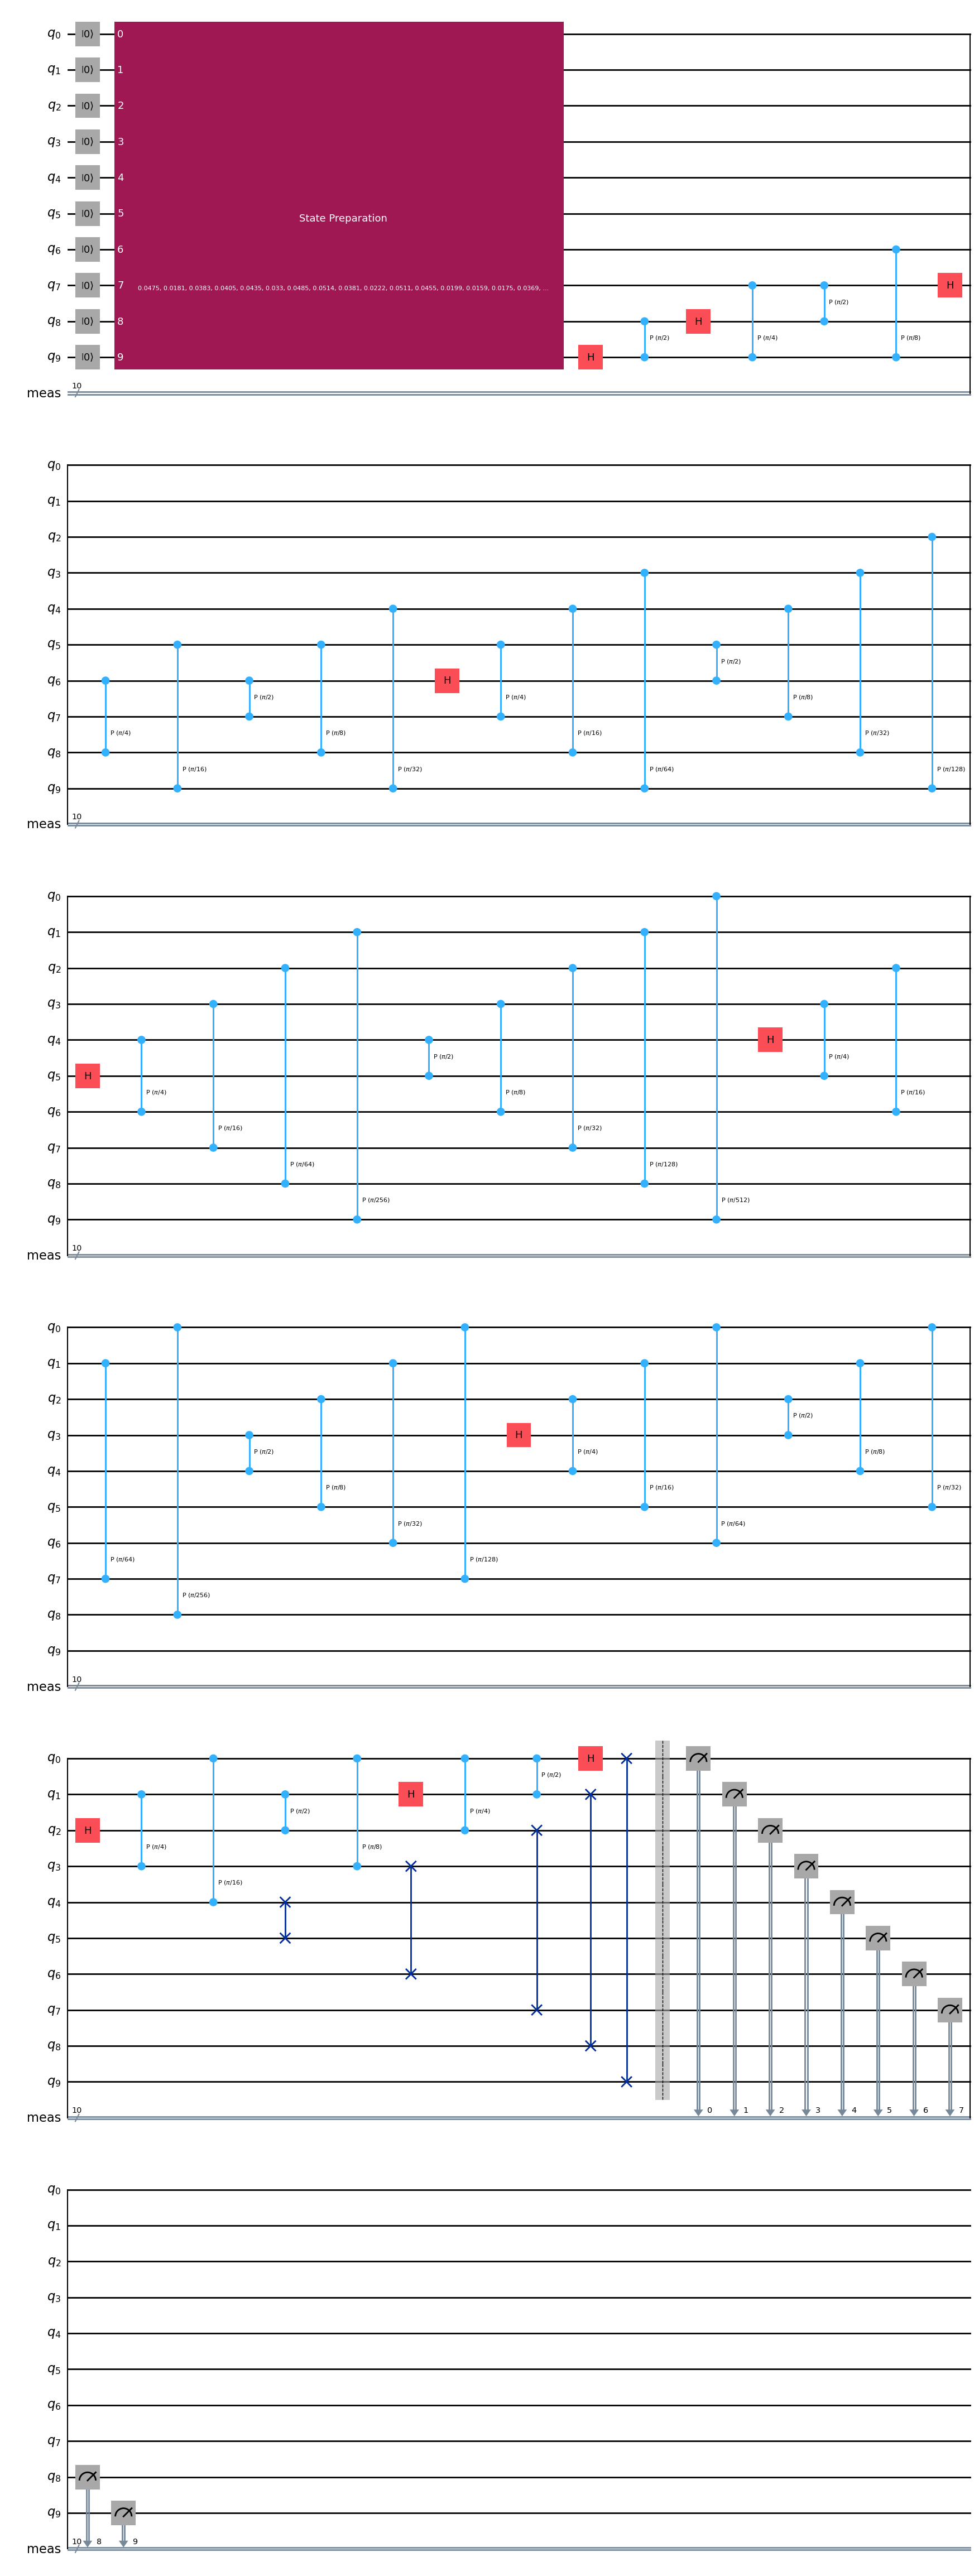

Relative L2 error |QFT_statevector|-|FFT|: 4.314e-16


Frequencies with peaks above 0.5 (QFT statevector): [np.float64(5.425), np.float64(10.851), np.float64(32.552)]
Relative phases between dominant peaks (degrees):
Phase difference between 5.425 Hz and 10.851 Hz: 94.981 degrees
Phase difference between 5.425 Hz and 32.552 Hz: 49.148 degrees
Phase difference between 10.851 Hz and 32.552 Hz: -45.833 degrees


In [53]:

def spectrum_from_QFT(signal, dt = dt,  shots=200000, compare_to_fft=True, statevector_access=False):

    qc_qft = QFT(signal)
    #show circuit diagram and make sure it displays in output
    display(qc_qft.decompose().draw('mpl'))

    N = len(signal)
    n_qubits = int(np.ceil(np.log2(N)))
    freq = sp.fft.fftfreq(N, dt)
    pos = freq >= 0

    # Classical FFT reference (complex + normalized magnitude)
    fft_complex = sp.fft.fft(signal)
    fft_mag_norm = np.abs(fft_complex) / (np.max(np.abs(fft_complex)) + 1e-15)

    # Shot-based measurement reconstruction (hardware-like)
    aer_qasm = AerSimulator()
    qc_meas_t = transpile(qc_qft, aer_qasm)
    result_meas = aer_qasm.run(qc_meas_t, shots=int(shots)).result()
    counts = result_meas.get_counts()

    p = np.zeros(N)
    for bitstr, c in counts.items():
        k = int(bitstr, 2)
        p[k] = c / int(shots)


    mag_meas = np.sqrt(p)
    mag_meas /= np.max(mag_meas) + 1e-15

    # Plot measurement reconstruction vs classical FFT
    fig_meas = go.Figure()
    fig_meas.add_trace(go.Scatter(x=freq[pos],y=mag_meas[pos],mode='lines',name=f'Measurement Reconstructed |X(f)| (shots={shots:,})'))

    if compare_to_fft:
        # Classical reference (normalized magnitude)
        fft_ref = np.abs(sp.fft.fft(signal))
        fft_ref /= np.max(fft_ref) + 1e-15
        fig_meas.add_trace(go.Scatter(x=freq[pos],y=fft_ref[pos],mode='lines',name='Classical FFT |X(f)| (normalized)',line=dict(dash='dash')))

    fig_meas.update_layout(title='One-Sided Spectrum: Measurement Reconstruction vs Classical FFT',xaxis_title='Frequency [Hz]',yaxis_title='Normalized Magnitude [arb.]')
    fig_meas.show()

    # Optional statevector reconstruction (full complex spectrum)
    if statevector_access:
        # Run statevector simulation to get full complex spectrum
        aer_sv = StatevectorSimulator()
        qc_sv_t = transpile(qc_qft.remove_final_measurements(inplace=False), aer_sv)
        result_sv = aer_sv.run(qc_sv_t).result()
        statevector_qft = np.asarray(result_sv.get_statevector(), dtype=complex)

        # Undo amplitude encoding normalization to match scipy.fft.fft(signal)
        statevector_qft = statevector_qft * np.sqrt(N) * np.linalg.norm(signal)

        # Reorder bins since state vector is little-endian but FFT output is big-endian
        rev = np.array([int(f"{i:0{n_qubits}b}"[::-1], 2) for i in range(N)], dtype=int)
        statevector_qft = statevector_qft[rev]

        mag_qft_norm = np.abs(statevector_qft) / (np.max(np.abs(statevector_qft)) + 1e-15)

        # Direct numerical check that statevector reconstruction matches classical FFT
        rel_err_sv_vs_fft = np.linalg.norm(np.abs(statevector_qft) - np.abs(fft_complex)) / (np.linalg.norm(np.abs(fft_complex)) + 1e-15)
        print(f'Relative L2 error |QFT_statevector|-|FFT|: {rel_err_sv_vs_fft:.3e}')

        # Plot statevector vs measurement vs FFT
        fig_sv = go.Figure()
        fig_sv.add_trace(go.Scatter(x=freq[pos], y=mag_qft_norm[pos], mode='lines', name='QFT Statevector |X(f)| (normalized)'))
        fig_sv.add_trace(go.Scatter(x=freq[pos], y=mag_meas[pos], mode='lines', name=f'Measurement Reconstructed |X(f)| (shots={int(shots):,})', line=dict(dash='dot')))
        fig_sv.add_trace(go.Scatter(x=freq[pos], y=fft_mag_norm[pos], mode='lines', name='Classical FFT |X(f)| (normalized)', line=dict(dash='dash')))
        fig_sv.update_layout(title='Spectrum Comparison: QFT Statevector vs Measurement vs Classical FFT', xaxis_title='Frequency [Hz]', yaxis_title='Normalized Magnitude [arb.]')
        fig_sv.show()

        # Peak list + robust relative phases from complex ratios
        freq_pos = freq[pos]
        mag_qft_pos = mag_qft_norm[pos]
        peak_idx = np.where(mag_qft_pos > 0.5)[0]
        print('Frequencies with peaks above 0.5 (QFT statevector):', [freq_pos[i].round(3) for i in peak_idx])

        print('Relative phases between dominant peaks (degrees):')
        for a in range(len(peak_idx)):
            for b in range(a + 1, len(peak_idx)):
                i = peak_idx[a]
                j = peak_idx[b]
                # angle(X_i * conj(X_j)) is stable against global phase offsets
                dphi = np.angle(statevector_qft[pos][i] * np.conj(statevector_qft[pos][j]), deg=True)
                print(f'Phase difference between {freq_pos[i].round(3)} Hz and {freq_pos[j].round(3)} Hz: {dphi:.3f} degrees')


spectrum_from_QFT(signal, shots=1e6, dt = dt, compare_to_fft=True, statevector_access=True)

We can see our reconstructed signal agrees exactly with our original signal, and our reconstructed spectrum agrees well with the classical FFT. The differences between the measurement reconstructed spectrum and the classical FFT are due to the finite number of shots used in the measurement process, which introduces some noise into the reconstructed spectrum. However, we can see that the main peaks in the spectrum are still present and correctly identified, indicating that the QFT is able to reconstruct the main features of the spectrum even with measurement noise.

Our peaks are at 5.425Hz, 10.85069Hz and 32.55208Hz which agrees with our classical FFT results. The relative phase between the peaks are also in good agreement with 94deg, 49deg and -45 deg which is exactly what we got from the classical FFT.

The main thing to keep in mind here is reconstructing phase information from measurements is not technically possible by simply using the QFT and measurements. Measuring quantum states destroy's phase information and only gives us access to the magnitude of our spectrum and doesn't give us real and imaginary signal components we use to reconstruct the phase. To do this we need to have access to the full state vector of the output state of the QFT, which is only possible in a simulator with statevector access.

# Q2d) 
having accesss to a quantum computer does offer some advantages over classical computing. The first one is that we need significantly less resources to encode our signal (only need 10 qubits to encode our entire signal!) as opposed to multiple bits per sample point in classical computing (on the order of kilobits for a 1000 sample points) The 2nd advantage is we only need to apply the QFT once to get our DFT values, whereas we need to apply the FFT for each frequency component we want to analyze in classical computing. This means that the QFT can be more efficient for large signals (low quantum memory requirements and faster computation time). 

The faster computation time is also related to the gate/circuit complexity of the QFT which is O(n^2) for n qubits (for F_{2n}) and efficient constructions for arbitrary QFT have been shown to have polynomial complexity, whereas the FFT has a complexity of O(N log N) for N sample points. So as our signal size increases the QFT can become more efficient than the FFT in terms of computation time (assuming we have a fault tolerant quantum computer with low error rates).

The main disadvantage of using a quantum computer as we've seen is that we cannot easily reconstruct the phase information of our spectrum directly using measurements. I wasn't able to find litterature or information online about modifications to the QFT that might allow this, but it is possible I missed something. 

